In [1]:
import os
import json
import pickle
import joblib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from scipy.sparse import load_npz
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device set to: {DEVICE}")

# Define Directories (Kaggle Paths)
ARTIFACT_DIR = '/kaggle/input/datasets/sherrytelli/bookbuddy-preprocessed/bookbuddy_artifacts'
MLP_DIR = '/kaggle/input/models/sherrytelli/mlp-bpr/pytorch/default/1'
NB_DIR = '/kaggle/input/models/sherrytelli/nbc/scikitlearn/default/1'

print("📦 Loading datasets and artifacts...")

# Load splits & artifacts
train_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'train.parquet'))
test_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'test.parquet'))

with open(os.path.join(ARTIFACT_DIR, 'artifacts.pkl'), 'rb') as f:
    artifacts = pickle.load(f)

n_users = len(artifacts['user_map'])
n_books = len(artifacts['book_map'])
reverse_book_map = {v: k for k, v in artifacts['book_map'].items()}

# Convert to implicit feedback (Threshold >= 4 means "Liked")
THRESHOLD = 4
def to_implicit(df):
    df = df.copy()
    df['label'] = (df['rating'] >= THRESHOLD).astype(int)
    return df[['user_idx', 'book_idx', 'label']]

train_imp = to_implicit(train_df)
test_imp = to_implicit(test_df)

# Fast-lookup dictionary for books the user has already interacted with
train_by_user = train_imp.groupby('user_idx')['book_idx'].apply(set).to_dict()

print(f"✅ Data loaded! Matrix dims: {n_users:,} users × {n_books:,} books")

✅ Device set to: cuda
📦 Loading datasets and artifacts...
✅ Data loaded! Matrix dims: 53,424 users × 8,726 books


In [2]:
import joblib

# 1. Re-define the MLP Architecture
class MLP_CF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=32, hidden_dims=[64, 32], dropout=0.3):
        super(MLP_CF, self).__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)
        
        layers = []
        input_dim = embed_dim * 2
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, user_idx, item_idx):
        u_emb = self.user_embed(user_idx)
        i_emb = self.item_embed(item_idx)
        x = torch.cat([u_emb, i_emb], dim=1)
        return self.mlp(x).squeeze(1)

# 2. Load the Optimized MLP Weights
model_config = torch.load(os.path.join(MLP_DIR, 'mlp_config_1.pt'), map_location=DEVICE)
mlp_model = MLP_CF(
    num_users=model_config['n_users'], 
    num_items=model_config['n_books'], 
    embed_dim=model_config['embed_dim'], 
    hidden_dims=model_config['hidden_dims'], 
    dropout=model_config['dropout']
).to(DEVICE)

mlp_model.load_state_dict(torch.load(os.path.join(MLP_DIR, 'mlp_bpr_weights_1.pt'), map_location=DEVICE))
mlp_model.eval() # Set to evaluation mode!
print("✅ MLP Collaborative Model Loaded!")

# 3. Load the Naïve Bayes Model
# ⚠️ UPDATE THIS FILENAME IF YOURS IS DIFFERENT
NB_MODEL_PATH = os.path.join(NB_DIR, 'nb_proficiency_model.pkl')

try:
    # Try using joblib instead of pickle
    nb_model = joblib.load(NB_MODEL_PATH)
    print("✅ Naïve Bayes Content Model Loaded!")
except Exception as e:
    print(f"❌ Error loading model: {e}")

✅ MLP Collaborative Model Loaded!
✅ Naïve Bayes Content Model Loaded!


In [6]:
class HybridRecommender:
    def __init__(self, mlp_model, nb_model, artifacts, books_df, tfidf_matrix, valid_nb_indices, device):
        self.mlp_model = mlp_model
        self.nb_model = nb_model 
        self.artifacts = artifacts
        self.books_df = books_df
        self.tfidf_matrix = tfidf_matrix
        self.device = device
        
        self.n_books = len(artifacts['book_map'])
        self.book_indices = torch.arange(self.n_books, device=self.device)
        self.scaler = MinMaxScaler()
        
        # Track the valid books
        self.valid_nb_indices = set(valid_nb_indices)
        
        # Pre-compute the NBC probabilities for ALL 8,726 books at once to save time
        # Shape will be (8726, 4) -> Probabilities for A2, B1, B2, C1
        self.nb_probs = self.nb_model.predict_proba(self.tfidf_matrix)

    @torch.no_grad()
    def get_mlp_scores(self, user_idx):
        """Gets Collaborative scores from the MLP & scales them to [0, 1]"""
        self.mlp_model.eval()
        user_vec = torch.full((self.n_books,), user_idx, dtype=torch.long, device=self.device)
        logits = self.mlp_model(user_vec, self.book_indices).cpu().numpy()
        scaled_scores = self.scaler.fit_transform(logits.reshape(-1, 1)).flatten()
        return scaled_scores

    def get_user_preferred_level(self, read_books):
        """Determines the user's dominant reading level from their history"""
        if not read_books:
            return 1 # Default to Intermediate (B1) if brand new user
            
        # Look up the proficiency labels of the books they've read
        read_levels = self.books_df.loc[list(read_books), 'proficiency_label'].dropna()
        
        if len(read_levels) == 0:
            return 1
            
        # Return their most frequent reading level (0, 1, 2, or 3)
        return int(read_levels.mode()[0])

    def get_nb_scores(self, user_idx, read_books):
        """Content Score = Probability that the book matches the user's reading level"""
        preferred_level = self.get_user_preferred_level(read_books)
        
        # Slice the probability matrix to get the scores for their specific level
        nb_full_scores = self.nb_probs[:, preferred_level]
        return nb_full_scores

    def recommend(self, user_idx, alpha=0.7, top_k=10, read_books=set()):
        """Fuses scores using alpha (MLP weight) and 1-alpha (NB weight)"""
        mlp_scores = self.get_mlp_scores(user_idx)
        nb_scores = self.get_nb_scores(user_idx, read_books)
        
        final_scores = np.zeros(self.n_books)
        
        for i in range(self.n_books):
            if i not in self.valid_nb_indices:
                # Content Cold Start: NBC is blind to this book, rely 100% on MLP
                final_scores[i] = mlp_scores[i]
            else:
                # NEW MULTIPLICATIVE FUSION
                # We use alpha to control how much the penalty hurts.
                # If alpha = 1.0, the NB score is ignored.
                # If alpha < 1.0, the NB score starts penalizing the MLP score.
                nb_penalty = (alpha) + ((1 - alpha) * nb_scores[i])
                final_scores[i] = mlp_scores[i] * nb_penalty
            
        # Mask out books the user has already read
        if read_books:
            final_scores[list(read_books)] = -float('inf')
            
        # Extract the Top K books
        top_k_indices = np.argsort(final_scores)[::-1][:top_k]
        
        # Translate internal indices back to real Goodreads IDs
        recommendations = [reverse_book_map[idx] for idx in top_k_indices]
        
        return recommendations, final_scores[top_k_indices]

print("✅ Smart HybridRecommender Class compiled successfully!")

✅ Smart HybridRecommender Class compiled successfully!


In [7]:
from scipy.sparse import load_npz

# 1. Load the Book Metadata & TF-IDF Matrix
books_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'books_clean.parquet'))
tfidf_matrix = load_npz(os.path.join(ARTIFACT_DIR, 'tfidf_matrix.npz'))

# 2. Map the text labels to match your NBC training (0, 1, 2, 3)
level_map = {'Beginner (A2)': 0, 'Intermediate (B1)': 1, 'Advanced (B2)': 2, 'Expert (C1)': 3}
books_df['proficiency_label'] = books_df['proficiency_level'].map(level_map)

# 3. Identify the 8,660 valid books
valid_nb_indices = books_df[books_df['proficiency_level'] != 'Unknown'].index.values

# 4. Initialize the Hybrid Engine
hybrid_engine = HybridRecommender(
    mlp_model=mlp_model, 
    nb_model=nb_model, 
    artifacts=artifacts, 
    books_df=books_df, 
    tfidf_matrix=tfidf_matrix, 
    valid_nb_indices=valid_nb_indices, 
    device=DEVICE
)
print("✅ Hybrid Engine Initialized!")

# 5. Test Inference on a Sample User!
SAMPLE_USER_IDX = 42 
user_read_books = train_by_user.get(SAMPLE_USER_IDX, set())

# Generate recommendations (70% Behavioral Collaborative, 30% Proficiency Matching)
recs, scores = hybrid_engine.recommend(user_idx=SAMPLE_USER_IDX, alpha=0.7, top_k=5, read_books=user_read_books)

print(f"\n📚 Top 5 Hybrid Recommendations for User {SAMPLE_USER_IDX}:")
for rank, (book_id, score) in enumerate(zip(recs, scores), 1):
    print(f"{rank}. Goodreads Book ID: {book_id} | Hybrid Score: {score:.4f}")

✅ Hybrid Engine Initialized!

📚 Top 5 Hybrid Recommendations for User 42:
1. Goodreads Book ID: 11 | Hybrid Score: 0.9392
2. Goodreads Book ID: 1 | Hybrid Score: 0.9320
3. Goodreads Book ID: 30 | Hybrid Score: 0.9186
4. Goodreads Book ID: 47 | Hybrid Score: 0.9082
5. Goodreads Book ID: 31 | Hybrid Score: 0.9078


🎯 PHASE 5: ALPHA PARAMETER TUNING
🔍 Searching for the optimal Alpha (Collaborative Weight)...
   Alpha: 0.0 | NDCG@10: 0.0476
   Alpha: 0.1 | NDCG@10: 0.0466
   Alpha: 0.2 | NDCG@10: 0.0536
   Alpha: 0.3 | NDCG@10: 0.0599
   Alpha: 0.4 | NDCG@10: 0.0539
   Alpha: 0.5 | NDCG@10: 0.0592
   Alpha: 0.6 | NDCG@10: 0.0641
   Alpha: 0.7 | NDCG@10: 0.0631
   Alpha: 0.8 | NDCG@10: 0.0737
   Alpha: 0.9 | NDCG@10: 0.0877
   Alpha: 1.0 | NDCG@10: 0.0834

🏆 Optimal Alpha Found: 0.9 (NDCG@10 = 0.0877)


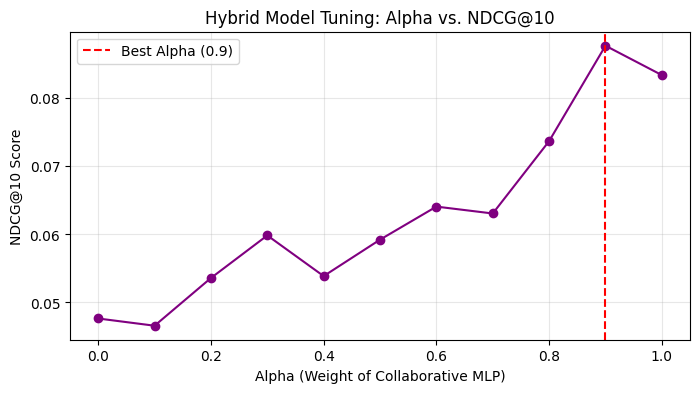

In [8]:
print("="*70)
print("🎯 PHASE 5: ALPHA PARAMETER TUNING")
print("="*70)

def evaluate_hybrid_fast(hybrid_engine, train_df, test_df, reverse_book_map, alpha, k=10, n_eval_users=300):
    """Fast evaluation focused only on NDCG@10 for quick tuning."""
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    valid_users = list(test_by_user.keys())
    sampled_users = np.random.choice(valid_users, size=min(n_eval_users, len(valid_users)), replace=False)
    
    ndcg_scores = []
    
    for u_idx in sampled_users:
        gt_internal = test_by_user[u_idx]
        gt_items = {reverse_book_map[idx] for idx in gt_internal}
        train_internal = train_by_user.get(u_idx, set())
        
        recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=alpha, top_k=k, read_books=train_internal)
        
        n_rel = len(gt_items)
        if n_rel == 0: continue
            
        dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recs) if item in gt_items)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            
    return np.mean(ndcg_scores)

# --- Run the Grid Search ---
alphas_to_test = np.arange(0.0, 1.1, 0.1)
tuning_results = []

print("🔍 Searching for the optimal Alpha (Collaborative Weight)...")
for a in alphas_to_test:
    # Notice we pass train_imp and test_imp here!
    score = evaluate_hybrid_fast(hybrid_engine, train_imp, test_imp, reverse_book_map, alpha=a)
    tuning_results.append(score)
    print(f"   Alpha: {a:.1f} | NDCG@10: {score:.4f}")

# Find the winner
best_alpha_idx = np.argmax(tuning_results)
best_alpha = alphas_to_test[best_alpha_idx]
peak_ndcg = tuning_results[best_alpha_idx]

print(f"\n🏆 Optimal Alpha Found: {best_alpha:.1f} (NDCG@10 = {peak_ndcg:.4f})")

# Plot the Alpha Curve
plt.figure(figsize=(8, 4))
plt.plot(alphas_to_test, tuning_results, marker='o', linestyle='-', color='purple')
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Best Alpha ({best_alpha:.1f})')
plt.title('Hybrid Model Tuning: Alpha vs. NDCG@10')
plt.xlabel('Alpha (Weight of Collaborative MLP)')
plt.ylabel('NDCG@10 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🎯 PHASE 6: COMPREHENSIVE HYBRID EVALUATION (Alpha = 0.9)
📈 TEST SET EVALUATION (Full Population)
----------------------------------------------------------------------


Evaluating users:   0%|          | 0/53172 [00:00<?, ?it/s]

Evaluated 53,172 users with test interactions

Precision@5:  0.0797
Recall@5:     0.0375
NDCG@5:       0.0863

Precision@10:  0.0668
Recall@10:     0.0625
NDCG@10:       0.0802

Precision@20:  0.0541
Recall@20:     0.1006
NDCG@20:       0.0913

🧊 COLD-START ROBUSTNESS ANALYSIS
----------------------------------------------------------------------
Simulating cold-start scenarios (NDCG@10):
History kept: 100%   | NDCG@10: 0.0828 ± 0.1214
History kept: 50%    | NDCG@10: 0.0698 ± 0.1087
History kept: 25%    | NDCG@10: 0.0611 ± 0.1037
History kept: 9%     | NDCG@10: 0.0579 ± 0.0988

📚 QUALITATIVE RECOMMENDATION SAMPLES
----------------------------------------------------------------------

User 1 (ID: 53344, 146 training ratings):
  1. The Fellowship of the Ring (The Lord of the Rings, #1)
  2. The Return of the King (The Lord of the Rings, #3)
  3. To Kill a Mockingbird
  4. The Two Towers (The Lord of the Rings, #2)
  5. Lord of the Flies

User 2 (ID: 11247, 143 training ratings):
  1. 19

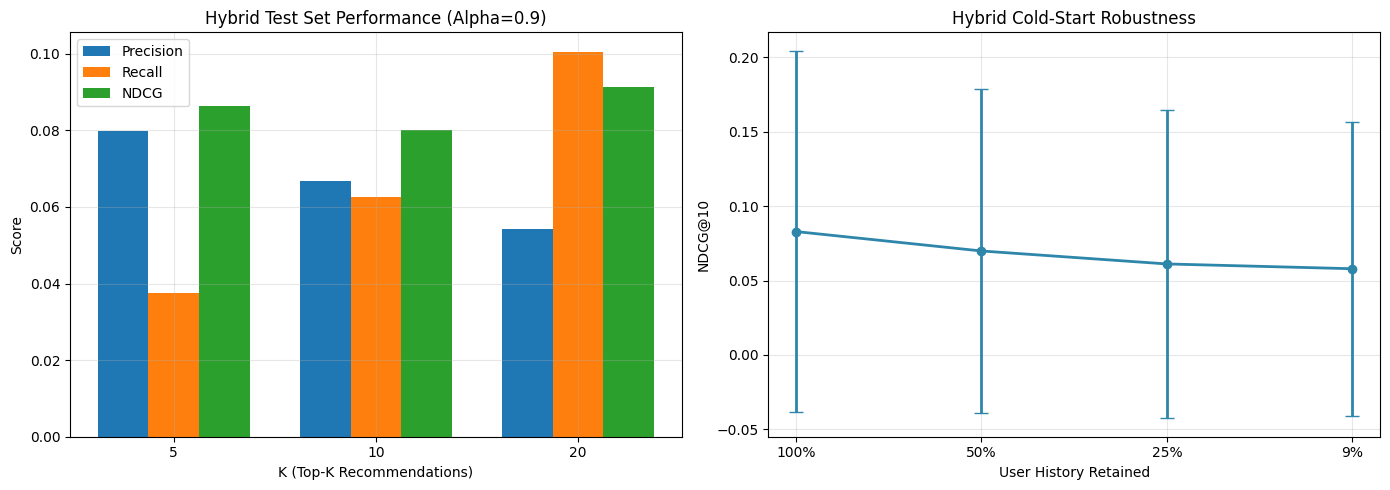


✅ Cell 7 Complete. The Hybrid Engine is fully evaluated!


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import json
import os

print("="*70)
print(f"🎯 PHASE 6: COMPREHENSIVE HYBRID EVALUATION (Alpha = {best_alpha:.1f})")
print("="*70)

# --- A. Full Test Set Evaluation (No Sampling) ---
print("📈 TEST SET EVALUATION (Full Population)")
print("-" * 70)

def evaluate_hybrid_full(hybrid_engine, train_df, test_df, reverse_book_map, alpha, k_values=[5, 10, 20]):
    """Evaluate Hybrid model on entire test set"""
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    metrics = {f'Precision@{k}': [] for k in k_values}
    metrics.update({f'Recall@{k}': [] for k in k_values})
    metrics.update({f'NDCG@{k}': [] for k in k_values})
    
    evaluated_users = 0
    
    for u_idx in tqdm(test_by_user.keys(), desc="Evaluating users"):
        gt_internal = test_by_user[u_idx]
        gt_items = {reverse_book_map[idx] for idx in gt_internal} # Convert to real IDs
        train_internal = train_by_user.get(u_idx, set())
        
        if len(gt_items) == 0:
            continue
        
        # Predict scores using the Hybrid Engine
        recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=alpha, top_k=max(k_values), read_books=train_internal)
        
        n_rel = len(gt_items)
        
        # Compute metrics
        for k in k_values:
            top_k_recs = recs[:k]
            hits = len(set(top_k_recs).intersection(gt_items))
            
            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0
            
            # NDCG
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_recs) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            
            metrics[f'Precision@{k}'].append(prec)
            metrics[f'Recall@{k}'].append(rec)
            metrics[f'NDCG@{k}'].append(ndcg)
            
        evaluated_users += 1
    
    final_metrics = {k: np.mean(v) for k, v in metrics.items()}
    return final_metrics, evaluated_users

# Run full test evaluation
hybrid_metrics, n_test_users = evaluate_hybrid_full(hybrid_engine, train_imp, test_imp, reverse_book_map, alpha=best_alpha, k_values=[5, 10, 20])

print(f"Evaluated {n_test_users:,} users with test interactions\n")
for k in [5, 10, 20]:
    print(f"Precision@{k}:  {hybrid_metrics[f'Precision@{k}']:.4f}")
    print(f"Recall@{k}:     {hybrid_metrics[f'Recall@{k}']:.4f}")
    print(f"NDCG@{k}:       {hybrid_metrics[f'NDCG@{k}']:.4f}")
    print()

# --- B. Cold-Start Simulation ---
print("="*70)
print("🧊 COLD-START ROBUSTNESS ANALYSIS")
print("-" * 70)

def simulate_hybrid_cold_start(hybrid_engine, train_df, test_df, reverse_book_map, alpha, mask_ratio=0.75, k=10, n_users=500):
    """
    Simulate cold-start by masking % of user training history.
    This also tests how well the Naïve Bayes proficiency fallback works with limited data!
    """
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    valid_users = [u for u in train_by_user if len(train_by_user[u]) > 10 and u in test_by_user]
    sampled_users = np.random.choice(valid_users, size=min(n_users, len(valid_users)), replace=False)
    
    ndcg_scores = []
    
    for u_idx in sampled_users:
        gt_internal = test_by_user[u_idx]
        gt_items = {reverse_book_map[idx] for idx in gt_internal}
        train_items = train_by_user.get(u_idx, set())
        
        if len(gt_items) == 0 or len(train_items) == 0:
            continue
        
        # Mask training items
        train_list = list(train_items)
        n_keep = max(1, int(len(train_list) * (1 - mask_ratio)))
        kept_items = set(np.random.choice(train_list, size=n_keep, replace=False))
        
        # Predict scores using ONLY the kept items
        # The hybrid engine will use 'kept_items' to figure out their reading level!
        recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=alpha, top_k=k, read_books=kept_items)
        
        # NDCG@K
        dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recs) if item in gt_items)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(gt_items), k)))
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)
    
    return np.mean(ndcg_scores), np.std(ndcg_scores)

hybrid_cold_start_results = {}
print("Simulating cold-start scenarios (NDCG@10):")
for mask_ratio in [0.0, 0.5, 0.75, 0.9]:
    mean_ndcg, std_ndcg = simulate_hybrid_cold_start(hybrid_engine, train_imp, test_imp, reverse_book_map, best_alpha, mask_ratio=mask_ratio, k=10, n_users=500)
    hybrid_cold_start_results[mask_ratio] = {'mean': mean_ndcg, 'std': std_ndcg}
    history_kept = f"{int((1-mask_ratio)*100)}%"
    print(f"History kept: {history_kept:6} | NDCG@10: {mean_ndcg:.4f} ± {std_ndcg:.4f}")

# --- C. Qualitative Recommendation Samples ---
print("\n" + "="*70)
print("📚 QUALITATIVE RECOMMENDATION SAMPLES")
print("-" * 70)

# Sample 3 active users
active_users = train_imp.groupby('user_idx').size().nlargest(3).index.tolist()

for i, u_idx in enumerate(active_users, 1):
    n_ratings = len(train_imp[train_imp['user_idx'] == u_idx])
    train_items = train_by_user.get(u_idx, set())
    
    recs, _ = hybrid_engine.recommend(user_idx=u_idx, alpha=best_alpha, top_k=5, read_books=train_items)
    
    print(f"\nUser {i} (ID: {u_idx}, {n_ratings} training ratings):")
    # Convert Goodreads IDs to Titles for pretty printing
    titles = []
    for r in recs:
        title_matches = books_df.loc[books_df[artifacts['id_col']] == r, 'title'].values
        titles.append(title_matches[0] if len(title_matches) > 0 else f"Unknown Title (ID: {r})")
        
    for rank, title in enumerate(titles, 1):
        print(f"  {rank}. {title}")

# --- D. Save Hybrid Predictions ---
print("\n" + "="*70)
print("💾 SAVING FINAL HYBRID ARTIFACTS")
print("-" * 70)

final_artifacts = {
    'hybrid_test_metrics': hybrid_metrics,
    'hybrid_cold_start_results': hybrid_cold_start_results,
    'hybrid_config': {
        'optimal_alpha': float(best_alpha),
        'fusion_type': 'Multiplicative Penalty'
    }
}

EVAL_DIR = 'evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)
file_path = os.path.join(EVAL_DIR, 'hybrid_evaluation_results.json')

with open(file_path, 'w') as f:
    json.dump(final_artifacts, f, indent=2)

print(f"✅ Saved hybrid_evaluation_results.json")

# --- E. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test metrics across K
k_values = [5, 10, 20]
metrics_to_plot = ['Precision', 'Recall', 'NDCG']
x = np.arange(len(k_values))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [hybrid_metrics[f'{metric}@{k}'] for k in k_values]
    axes[0].bar(x + i*width, values, width, label=f'{metric}')

axes[0].set_xlabel('K (Top-K Recommendations)')
axes[0].set_ylabel('Score')
axes[0].set_title(f'Hybrid Test Set Performance (Alpha={best_alpha:.1f})')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cold-start degradation
mask_ratios = list(hybrid_cold_start_results.keys())
ndcg_means = [hybrid_cold_start_results[r]['mean'] for r in mask_ratios]
ndcg_stds = [hybrid_cold_start_results[r]['std'] for r in mask_ratios]
history_pct = [f"{int((1-r)*100)}%" for r in mask_ratios]

axes[1].errorbar(history_pct, ndcg_means, yerr=ndcg_stds, marker='o', capsize=5, 
                 linewidth=2, color='#2E86AB')
axes[1].set_xlabel('User History Retained')
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('Hybrid Cold-Start Robustness')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 7 Complete. The Hybrid Engine is fully evaluated!")